<a href="https://colab.research.google.com/github/AmitavaDutta/parallel_data_processing_engine/blob/main/GPU_versions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Device] GPU detected: Tesla T4
[Data] Generated 8000 series of length 100000 (3051.8 MB)

--- Running: CPU Baseline ---
--- Running: GPU Full + Pageable ---
--- Running: GPU Full + Pinned ---
--- Running: GPU Blockwise + Pageable ---
--- Running: GPU Blockwise + Pinned ---

[Success] Data saved to 'final_benchmark_results.csv'. Generating plots...


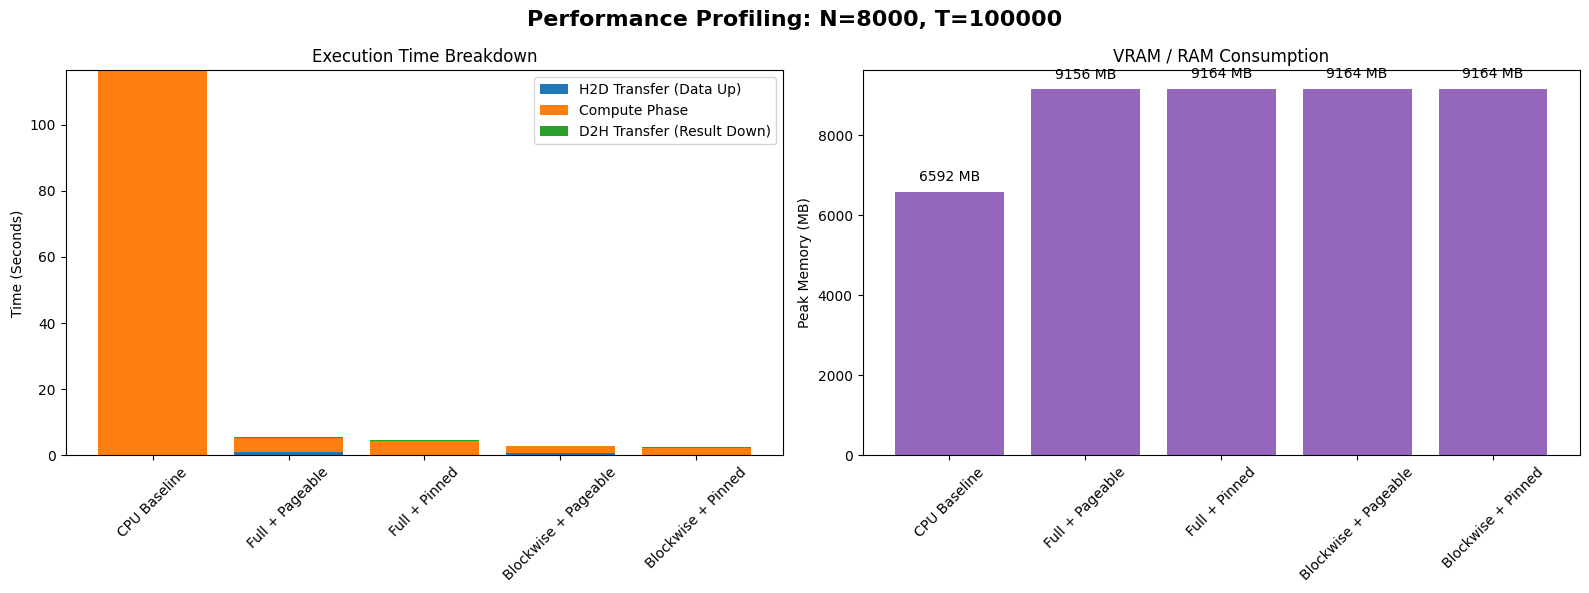

In [1]:
"""
GPU vs CPU Correlation Matrix Computation & Benchmarking
DS Practice Project - Final Version

This script calculates an N×N correlation matrix for N time series.
It systematically tests the communication pipeline and VRAM limits by comparing:
1. CPU Baseline
2. GPU Full Matrix + Pageable Memory
3. GPU Full Matrix + Pinned Memory
4. GPU Blockwise + Pageable Memory
5. GPU Blockwise + Pinned Memory

Results are saved to a CSV and visualized using Matplotlib.
"""

import torch
import numpy as np
import time
import tracemalloc
import csv
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Helpers & Baselines
# ─────────────────────────────────────────────────────────────────────────────
def get_device():
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        print(f"[Device] GPU detected: {gpu_name}")
        return torch.device("cuda")
    print("[Device] No GPU detected. Script will only run CPU baseline.")
    return torch.device("cpu")

def generate_data(N: int, T: int, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    data = rng.standard_normal((N, T)).astype(np.float32)
    print(f"[Data] Generated {N} series of length {T} ({data.nbytes / 1024**2:.1f} MB)")
    return data

def cpu_correlation(data: np.ndarray):
    print("\n--- Running: CPU Baseline ---")
    tracemalloc.start()
    t0 = time.perf_counter()

    corr_matrix = np.corrcoef(data)

    exec_time = time.perf_counter() - t0
    _, peak_mem_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "Configuration": "CPU Baseline",
        "H2D_Time": 0.0,
        "Compute_Time": exec_time,
        "D2H_Time": 0.0,
        "Total_Time": exec_time,
        "Peak_Memory_MB": peak_mem_bytes / (1024**2)
    }

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Transfer Wrappers
# ─────────────────────────────────────────────────────────────────────────────
def transfer_pageable(data_numpy, device):
    t0 = time.perf_counter()
    X_gpu = torch.tensor(data_numpy, device=device)
    torch.cuda.synchronize()
    return X_gpu, time.perf_counter() - t0

def transfer_pinned(data_numpy, device):
    cpu_pinned = torch.from_numpy(data_numpy).pin_memory()
    t0 = time.perf_counter()
    X_gpu = cpu_pinned.to(device)
    torch.cuda.synchronize()
    return X_gpu, time.perf_counter() - t0

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: GPU Strategies
# ─────────────────────────────────────────────────────────────────────────────
def gpu_correlation_full(data, device, mode):
    print(f"--- Running: GPU Full + {mode.capitalize()} ---")
    torch.cuda.reset_peak_memory_stats()

    # 1. H2D
    if mode == "pageable": X, h2d_t = transfer_pageable(data, device)
    else:                  X, h2d_t = transfer_pinned(data, device)

    # 2. Compute
    t1 = time.perf_counter()
    mean = X.mean(dim=1, keepdim=True)
    std = torch.clamp(X.std(dim=1, keepdim=True, unbiased=False), min=1e-8)
    Z = (X - mean) / std
    corr = torch.mm(Z, Z.T) / data.shape[1]
    torch.cuda.synchronize()
    comp_t = time.perf_counter() - t1

    # 3. D2H
    t2 = time.perf_counter()
    res = corr.cpu().numpy()
    torch.cuda.synchronize()
    d2h_t = time.perf_counter() - t2

    return {
        "Configuration": f"Full + {mode.capitalize()}",
        "H2D_Time": h2d_t, "Compute_Time": comp_t, "D2H_Time": d2h_t,
        "Total_Time": h2d_t + comp_t + d2h_t,
        "Peak_Memory_MB": torch.cuda.max_memory_allocated(0) / (1024**2)
    }

def gpu_correlation_blockwise(data, device, mode, block_size=2048):
    print(f"--- Running: GPU Blockwise + {mode.capitalize()} ---")
    torch.cuda.reset_peak_memory_stats()
    N, T = data.shape

    # 1. H2D
    if mode == "pageable": X, h2d_t = transfer_pageable(data, device)
    else:                  X, h2d_t = transfer_pinned(data, device)

    # 2. Compute
    t1 = time.perf_counter()
    mean = X.mean(dim=1, keepdim=True)
    std = torch.clamp(X.std(dim=1, keepdim=True, unbiased=False), min=1e-8)
    Z = (X - mean) / std

    corr_matrix = torch.zeros((N, N), device=device)
    num_blocks = (N + block_size - 1) // block_size

    for i in range(num_blocks):
        i_s, i_e = i*block_size, min((i+1)*block_size, N)
        for j in range(i, num_blocks):
            j_s, j_e = j*block_size, min((j+1)*block_size, N)
            block = torch.mm(Z[i_s:i_e, :], Z[j_s:j_e, :].T) / T
            corr_matrix[i_s:i_e, j_s:j_e] = block
            if i != j: corr_matrix[j_s:j_e, i_s:i_e] = block.T

    torch.cuda.synchronize()
    comp_t = time.perf_counter() - t1

    # 3. D2H
    t2 = time.perf_counter()
    res = corr_matrix.cpu().numpy()
    torch.cuda.synchronize()
    d2h_t = time.perf_counter() - t2

    return {
        "Configuration": f"Blockwise + {mode.capitalize()}",
        "H2D_Time": h2d_t, "Compute_Time": comp_t, "D2H_Time": d2h_t,
        "Total_Time": h2d_t + comp_t + d2h_t,
        "Peak_Memory_MB": torch.cuda.max_memory_allocated(0) / (1024**2)
    }

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Visualization & Reporting
# ─────────────────────────────────────────────────────────────────────────────
def plot_results(results, N, T):
    configs = [r["Configuration"] for r in results]
    h2d = [r["H2D_Time"] for r in results]
    comp = [r["Compute_Time"] for r in results]
    d2h = [r["D2H_Time"] for r in results]
    mems = [r["Peak_Memory_MB"] for r in results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Performance Profiling: N={N}, T={T}", fontsize=16, fontweight='bold')

    # Plot 1: Stacked Bar Chart for Time Breakdown
    ax1.bar(configs, h2d, label='H2D Transfer (Data Up)', color='#1f77b4')
    ax1.bar(configs, comp, bottom=h2d, label='Compute Phase', color='#ff7f0e')
    bottom_d2h = [i+j for i,j in zip(h2d, comp)]
    ax1.bar(configs, d2h, bottom=bottom_d2h, label='D2H Transfer (Result Down)', color='#2ca02c')

    ax1.set_ylabel('Time (Seconds)')
    ax1.set_title('Execution Time Breakdown')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend()

    # Plot 2: Bar Chart for Peak Memory
    bars = ax2.bar(configs, mems, color='#9467bd')
    ax2.set_ylabel('Peak Memory (MB)')
    ax2.set_title('VRAM / RAM Consumption')
    ax2.tick_params(axis='x', rotation=45)

    # Add memory text labels
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(mems)*0.02),
                 f'{yval:.0f} MB', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# MAIN EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    N, T = 8000, 100000  # Adjust N higher to see VRAM crashes on Full Strategy
    device = get_device()
    data = generate_data(N, T)
    results = []

    # 1. CPU Baseline
    results.append(cpu_correlation(data))

    if device.type == "cuda":
        # 2 & 3. GPU Full Strategy (Pageable then Pinned)
        results.append(gpu_correlation_full(data, device, mode="pageable"))
        results.append(gpu_correlation_full(data, device, mode="pinned"))

        # 4 & 5. GPU Blockwise Strategy (Pageable then Pinned)
        results.append(gpu_correlation_blockwise(data, device, mode="pageable"))
        results.append(gpu_correlation_blockwise(data, device, mode="pinned"))

    # Save to CSV
    with open("final_benchmark_results.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=results[0].keys())
        writer.writeheader()
        writer.writerows(results)

    print("\n[Success] Data saved to 'final_benchmark_results.csv'. Generating plots...")

    # Generate Plots
    plot_results(results, N, T)